# Project 1: Stock trend

***Objective*** : Use Markov chain to model stock trend and application in forecasting

1. Collect daily stock price data (VN index, VCB, ... )
2. Transform stock price data into trend as followings:
  -  Step 1: Compute daily return $r_t = \frac{x_t - x_{t-1}}{x_{t-1}}$  where $x_t$ is the stock price at day $t$.
  - Step 2: Assign trend :
    
    * choose convenience thresholds $a>b$
    * if $r_t>a$: the trend at day $t$ is up
    *  if $r_t<b$ : the trend at day $t$ is down
    * if $b \leq r_t\leq a$: the trend at day $t$ is flat (neutral)


3. Suppose that the sequence of trend $(T_t)_{t}$ is modelled by a Markov chain. Estimate the transition probability matrix for the trend process.
4. Forecast the trend in the next 5 days.

In [46]:
!pip install quantecon
!pip install yfinance quantecon

In [47]:
import numpy             as np
import pandas            as pd
import yfinance          as yf
import quantecon         as qe
import matplotlib.pyplot as plt
import matplotlib.dates  as mdates
import seaborn           as sns

from   datetime          import datetime, timedelta

In [48]:
def estimate_transition_matrix(data, states):
    state_to_int = {state: i for i, state in enumerate(states)}
    n_states = len(states)
    counts = np.zeros((n_states, n_states), dtype=int)

    for i in range(len(data) - 1):
        if data[i] in state_to_int and data[i+1] in state_to_int:
            from_state_idx = state_to_int[data[i]]
            to_state_idx = state_to_int[data[i+1]]
            counts[from_state_idx, to_state_idx] += 1

    transition_matrix = counts.astype(float)
    row_sums = transition_matrix.sum(axis=1)
    row_sums[row_sums == 0] = 1
    transition_matrix = transition_matrix / row_sums[:, np.newaxis]

    return transition_matrix, state_to_int



# Collect Daily Stock Price Data
ticker = "VCB.VN"
print(f"Downloading data for {ticker}...")

# Date Range: Last 3 years
stock_data = yf.download(ticker, start=(datetime.now() - timedelta(days=3*365)).strftime('%Y-%m-%d'), end=datetime.now().strftime('%Y-%m-%d'))

# Transform Data into Trends
# Ensure we convert the data to a flat numpy array of floats
returns = stock_data['Close'].pct_change().dropna().to_numpy().flatten()

# Convert returns to a pandas Series to use the quantile method
returns_series = pd.Series(returns)
a = returns_series.quantile(0.66)
b = returns_series.quantile(0.33)

trend_sequence = []
for r in returns:
    if r > a:
        trend_sequence.append('Up')
    elif r < b:
        trend_sequence.append('Down')
    else:
        trend_sequence.append('Flat')

print(f"First 10 trends: {trend_sequence[:10]}")



# Estimate Transition Matrix
unique_states = ['Up', 'Flat', 'Down']
P_matrix, mapping = estimate_transition_matrix(trend_sequence, unique_states)

print("Estimated Transition Matrix")
print(f"States: {unique_states}")
print(np.round(P_matrix, 3))

mc_stock = qe.MarkovChain(P_matrix, unique_states)



# Forecast Trend for Next 5 Days
last_trend = trend_sequence[-1]
print(f"\nLast observed trend: {last_trend}")

forecast_path = mc_stock.simulate(ts_length=6, init=last_trend)
print(f"Forecast for next 5 days: {forecast_path[1:]}")

/tmp/ipython-input-590743503.py:26: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(ticker, start=(datetime.now() - timedelta(days=3*365)).strftime('%Y-%m-%d'), end=datetime.now().strftime('%Y-%m-%d'))
[*********************100%***********************]  1 of 1 completed

First 10 trends: ['Down', 'Up', 'Down', 'Flat', 'Down', 'Flat', 'Up', 'Flat', 'Up', 'Down']
Estimated Transition Matrix
States: ['Up', 'Flat', 'Down']
[[0.407 0.233 0.36 ]
 [0.27  0.43  0.299]
 [0.341 0.329 0.329]]

Last observed trend: Flat
Forecast for next 5 days: ['Up' 'Up' 'Flat' 'Down' 'Flat']


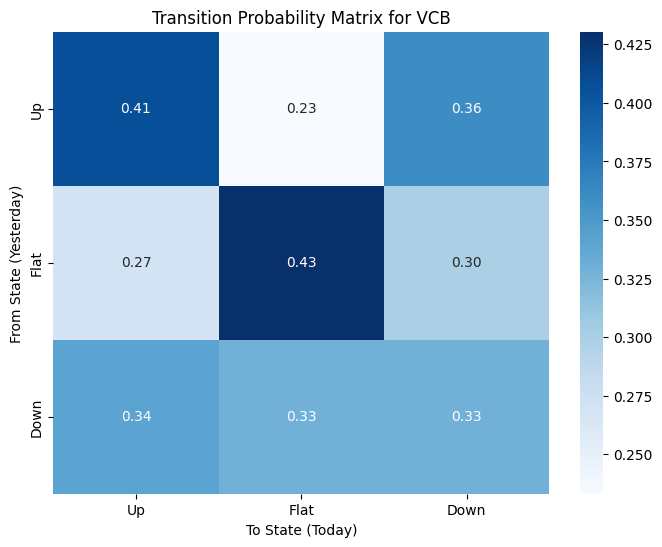

In [49]:
# Create a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(P_matrix, annot=True, cmap='Blues', fmt='.2f',
            xticklabels=unique_states, yticklabels=unique_states)
plt.title(f'Transition Probability Matrix for VCB')
plt.ylabel('From State (Yesterday)')
plt.xlabel('To State (Today)')
plt.show()


--- Long-run Stationary Distribution ---
Time spent Up: 34.04%
Time spent Flat: 32.99%
Time spent Down: 32.97%


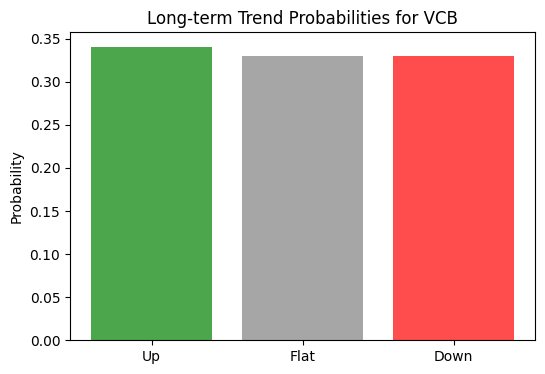

In [50]:
# Get the stationary distribution (long-run probabilities)
stationary_dist = mc_stock.stationary_distributions[0]

print("\n--- Long-run Stationary Distribution ---")
for state, prob in zip(unique_states, stationary_dist):
    print(f"Time spent {state}: {prob:.2%}")

# Plot it
plt.figure(figsize=(6, 4))
colors = ['green', 'gray', 'red']
plt.bar(unique_states, stationary_dist, color=colors, alpha=0.7)
plt.title(f"Long-term Trend Probabilities for VCB")
plt.ylabel("Probability")
plt.show()

# Prepare data for plotting

In [51]:
# 1. Get Dates and Prices (excluding the first day because it has no return)
dates = stock_data.index[1:]
prices = stock_data['Close'].to_numpy().flatten()[1:] # Flatten to ensure it's a 1D array

# 2. Create numerical values for the trends for the Step Plot
# Up = 1, Flat = 0, Down = -1
trend_map = {'Up': 1, 'Flat': 0, 'Down': -1}
numeric_trends = [trend_map[t] for t in trend_sequence]

# Plotting

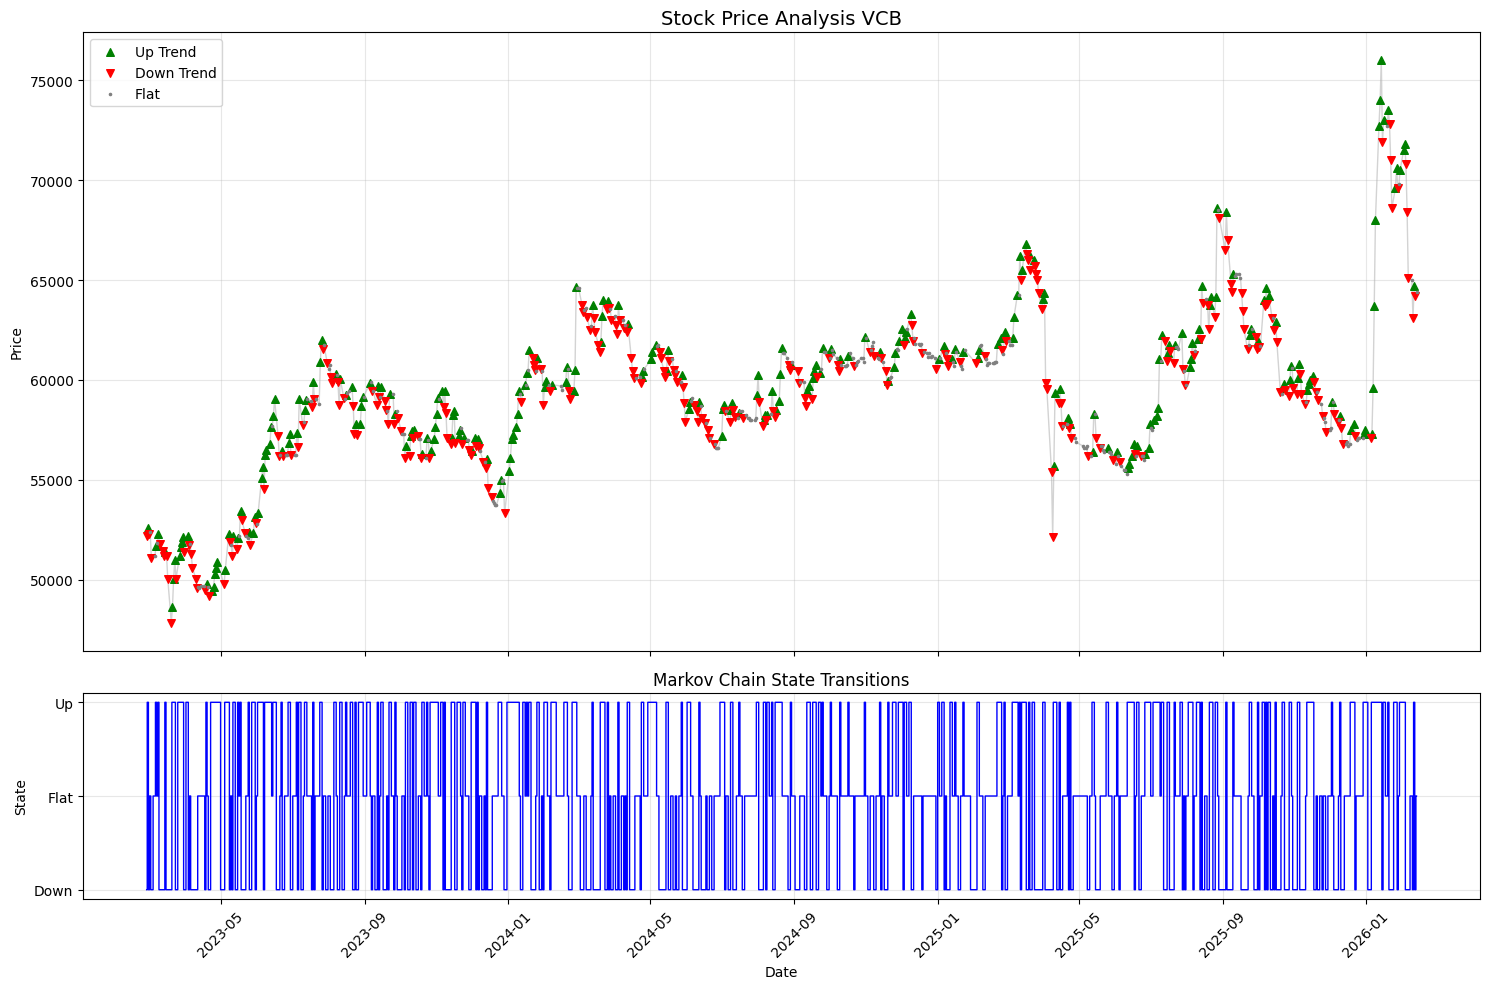

In [52]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# CHART 1: Price History with Colored Trends
ax1.plot(dates, prices, color='lightgray', linewidth=1, zorder=1)

# Create masks for boolean indexing
up_mask = np.array(trend_sequence) == 'Up'
down_mask = np.array(trend_sequence) == 'Down'
flat_mask = np.array(trend_sequence) == 'Flat'

# Plot Up (Green Triangle)
ax1.scatter(dates[up_mask], prices[up_mask], color='green', marker='^', label='Up Trend', s=30, zorder=2)
# Plot Down (Red Inverted Triangle)
ax1.scatter(dates[down_mask], prices[down_mask], color='red', marker='v', label='Down Trend', s=30, zorder=2)
# Plot Flat (Grey Dot)
ax1.scatter(dates[flat_mask], prices[flat_mask], color='gray', marker='.', label='Flat', s=10, zorder=2)

ax1.set_title(f'Stock Price Analysis VCB', fontsize=14)
ax1.set_ylabel('Price')
ax1.legend()
ax1.grid(True, alpha=0.3)

# CHART 2: Discrete Markov States (-1, 0, 1)
ax2.step(dates, numeric_trends, where='mid', color='blue', linewidth=1)
ax2.set_yticks([-1, 0, 1])
ax2.set_yticklabels(['Down', 'Flat', 'Up'])
ax2.set_title('Markov Chain State Transitions', fontsize=12)
ax2.set_ylabel('State')
ax2.grid(True, alpha=0.3)

# Format Date Axis
plt.xlabel('Date')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# BACKTESTING

In [53]:
# 1. Split Data
# We hide the last 5 days to see if the model could have predicted them
n_test = 5
train_data = trend_sequence[:-n_test] # All data except last 5 days
actual_last_5_days = trend_sequence[-n_test:] # The real last 5 days

# 2. Estimate matrix on train data only
P_matrix_train, mapping_train = estimate_transition_matrix(train_data, unique_states)
mc_train = qe.MarkovChain(P_matrix_train, unique_states)

# 3. Predict
start_state = train_data[-1] # The state just before the test set
# We simulate 10 paths to see the "Average" prediction
simulated_paths = []
for _ in range(10):
    # length=6 because it includes the start state + 5 new steps
    simulated_paths.append(mc_train.simulate(ts_length=n_test+1, init=start_state)[1:])

print(f"Actual last 5 days:    {actual_last_5_days}")
print(f"Simulation : {simulated_paths[0]}")
# Note: Since Markov Chains are random, the simulation won't match perfectly every time.

Actual last 5 days:    ['Flat', 'Down', 'Up', 'Down', 'Flat']
Simulation : ['Up' 'Down' 'Up' 'Down' 'Up']


# FORECAST FUTURE PRICE


Calculated Avg Up Return: 1.3299%
Calculated Avg Down Return: -1.2176%


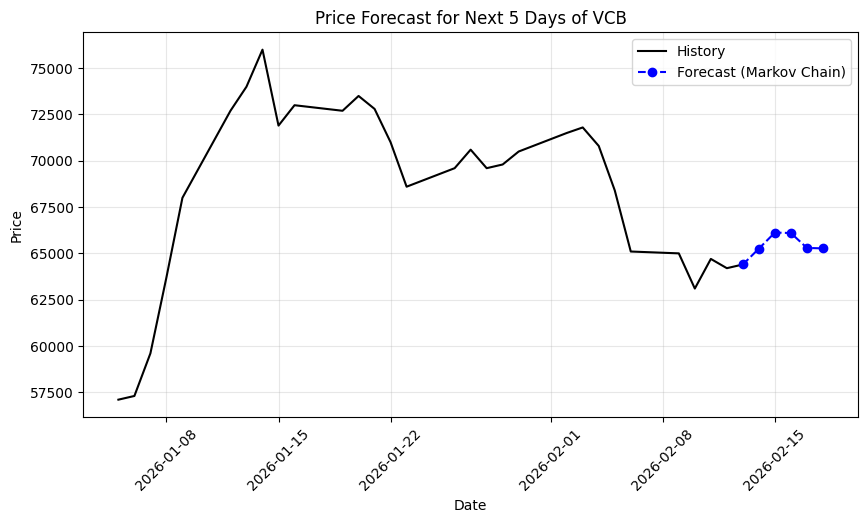

In [54]:
# 1. Define average return for each state (calcuated from the data)
# We zip the returns and the trend sequence to find the actual average
# Create a temporary dataframe to calculate means easily
df_analysis = pd.DataFrame({'Return': returns, 'Trend': trend_sequence})

# Calculate the actual average return for Up days and Down days
avg_up_return = df_analysis[df_analysis['Trend'] == 'Up']['Return'].mean()
avg_down_return = df_analysis[df_analysis['Trend'] == 'Down']['Return'].mean()
avg_flat_return = df_analysis[df_analysis['Trend'] == 'Flat']['Return'].mean()

print(f"Calculated Avg Up Return: {avg_up_return:.4%}")
print(f"Calculated Avg Down Return: {avg_down_return:.4%}")

# 2. Get the last actual price
current_price = prices[-1]
future_prices = [current_price]

# 3. Calculate future price path based on the simulated trends
# forecast_path contains states like 'Up', 'Down'...
for state in forecast_path[1:]: # Skip the first one as it is the current state
    if state == 'Up':
        current_price = current_price * (1 + avg_up_return)
    elif state == 'Down':
        current_price = current_price * (1 + avg_down_return)
    else:
        current_price = current_price * (1 + avg_flat_return)
    future_prices.append(current_price)

# 4. Create Future Dates
last_date = dates[-1]
future_dates = [last_date + pd.Timedelta(days=i) for i in range(len(future_prices))]

# 5. Plot the Forecast
plt.figure(figsize=(10, 5))
# Plot last 30 days of history
plt.plot(dates[-30:], prices[-30:], label='History', color='black')
# Plot Forecast
plt.plot(future_dates, future_prices, label='Forecast (Markov Chain)', color='blue', linestyle='--', marker='o')

plt.title(f'Price Forecast for Next 5 Days of VCB')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.show()